<a href="https://colab.research.google.com/github/Amarmurun0212/Diver/blob/main/AI%26MLLes8MultibleReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multible linear regression

=== ДАТАНЫ ЭХНИЙ 5 МӨР ===
   area_m2  num_occupants  avg_temp  insulation  appliances_count  \
0      132              1        -6           5                 8   
1      209              3        -2           2                26   
2      122              4       -14           1                 6   
3       44              1        24           3                14   
4      136              1         9           3                 9   

   solar_panel  humidity  energy_kwh  
0            1        80      568.31  
1            0        54     1554.88  
2            1        69     1047.65  
3            1        81       65.04  
4            1        36      627.46  


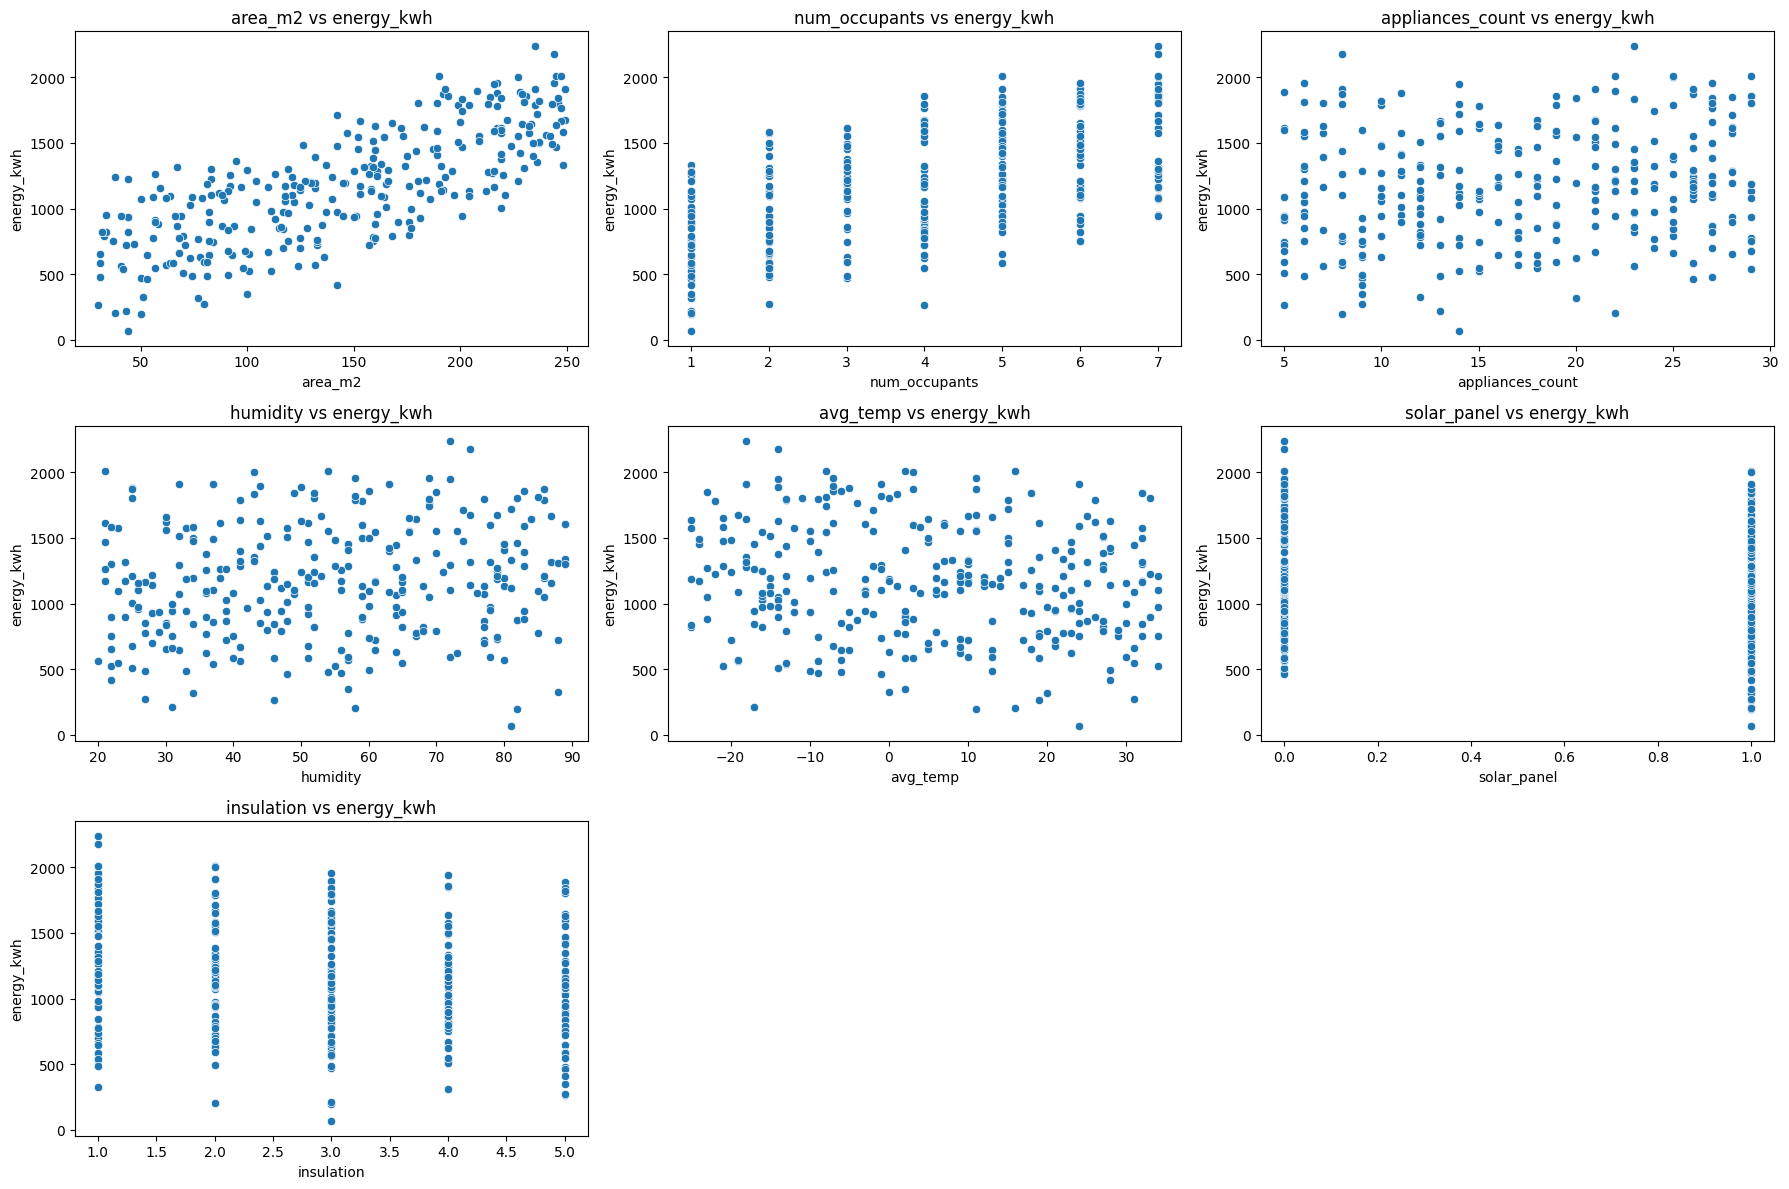


=== КОРРЕЛЯЦЫН МАТРИЦ ===
                   area_m2  num_occupants  avg_temp  insulation  \
area_m2           1.000000       0.002767 -0.005481   -0.006101   
num_occupants     0.002767       1.000000 -0.017131   -0.113496   
avg_temp         -0.005481      -0.017131  1.000000    0.001775   
insulation       -0.006101      -0.113496  0.001775    1.000000   
appliances_count  0.027030      -0.011153  0.079013   -0.102734   
solar_panel      -0.009065      -0.004130  0.084994   -0.099158   
humidity          0.106182       0.017013 -0.070857   -0.062046   
energy_kwh        0.759594       0.582570 -0.146696   -0.202017   

                  appliances_count  solar_panel  humidity  energy_kwh  
area_m2                   0.027030    -0.009065  0.106182    0.759594  
num_occupants            -0.011153    -0.004130  0.017013    0.582570  
avg_temp                  0.079013     0.084994 -0.070857   -0.146696  
insulation               -0.102734    -0.099158 -0.062046   -0.202017  
appliance

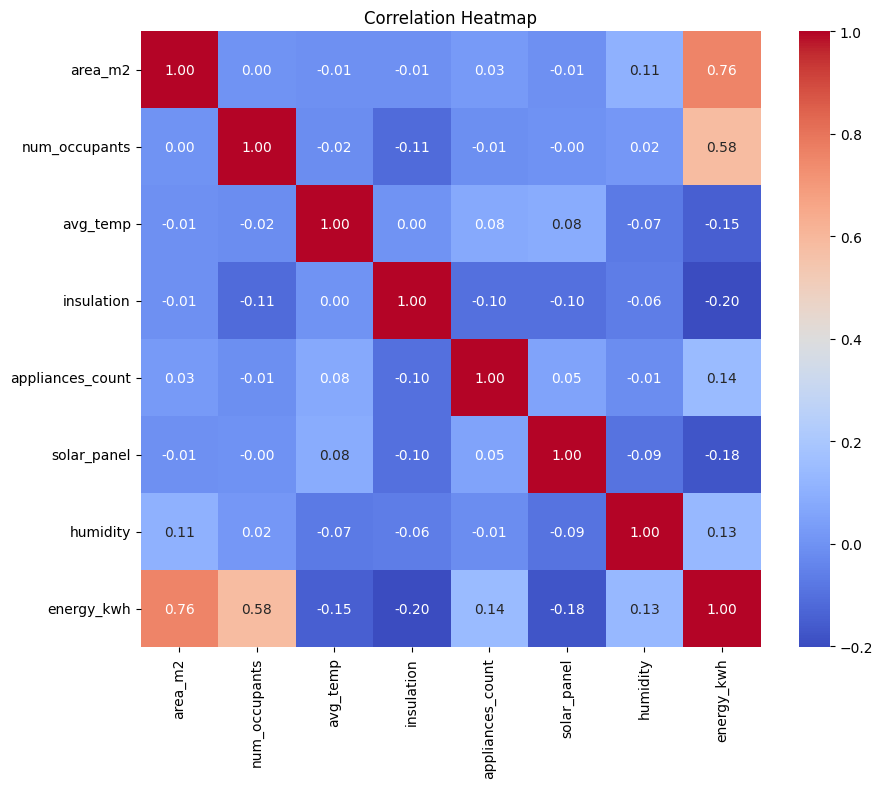


=== MODEL ҮНЭЛГЭЭ ===
MAE  : 25.69
MSE  : 1087.80
R2   : 0.9944

=== FEATURE КОЭФФИЦИЕНТ ===
            Feature  Coefficient
0           area_m2     5.035033
1     num_occupants   120.418478
2  appliances_count     7.697835
3          humidity     0.275386
4          avg_temp    -3.198526
5       solar_panel  -152.058270
6        insulation   -41.599425

=== ШИНЭ ӨГӨГДЛӨӨР PREDICT ХИЙХ ===
area_m2 оруулна уу: 100
num_occupants оруулна уу: 2
appliances_count оруулна уу: 2
humidity оруулна уу: 5
avg_temp оруулна уу: 5
solar_panel (0 эсвэл 1): 5
insulation оруулна уу: 52

=== PREDICT ҮР ДҮН ===
Таамагласан energy_kwh: -2161.74


'\nKEYWORD ТАЙЛБАР:\n\n1. DataFrame\n   -> pandas сангийн хүснэгтэн бүтэцтэй өгөгдөл\n\n2. Feature\n   -> Model-д орж буй input хувьсагч\n\n3. Target\n   -> Predict хийх гэж буй утга\n   -> Энэ жишээнд energy_kwh\n\n4. Correlation\n   -> 2 хувьсагчийн хамаарлын хүч\n\n5. Heatmap\n   -> Корреляцыг өнгөөр харуулдаг график\n\n6. train_test_split\n   -> Датаг train болон test хэсэгт хуваана\n\n7. Linear Regression\n   -> Шугаман хамаарлаар predict хийдэг ML алгоритм\n\n8. fit()\n   -> Model сургах\n\n9. predict()\n   -> Шинэ утга таамаглах\n\n10. MAE\n    -> Дундаж абсолют алдаа\n\n11. MSE\n    -> Дундаж квадрат алдаа\n\n12. R2 Score\n    -> Model хэдэн хувь зөв тайлбарлаж байгааг хэмжинэ\n'

In [ ]:

# ================================
# Energy хэрэглээний дата анализ
# Multiple Linear Regression ашиглан таамаглал хийх
# ================================

# Шаардлагатай сангуудыг import хийх
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Машин сургалтын сангууд
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------
# 1. CSV файлыг унших
# --------------------------------
# NOTE:
# energy_data(1).csv файл нь энэ .py файлтай нэг хавтсанд байх ёстой
df = pd.read_csv("energy_data.csv")

# Эхний 5 мөрийг хэвлэх
print("=== ДАТАНЫ ЭХНИЙ 5 МӨР ===")
print(df.head())

# --------------------------------
# 2. График байгуулах
# --------------------------------

# energy_kwh-тэй харьцуулах баганууд
features = [
    'area_m2',
    'num_occupants',
    'appliances_count',
    'humidity',
    'avg_temp',
    'solar_panel',
    'insulation'
]

# Графикийн хэмжээ
plt.figure(figsize=(18, 12))

# Бүх feature тус бүрээр scatter plot үүсгэх
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=feature,
        y='energy_kwh'
    )

    plt.title(f'{feature} vs energy_kwh')

# Графикуудын зайг тохируулах
plt.tight_layout()

# Зураг хадгалах
plt.savefig("scatter_plots.png")

# Дэлгэцэнд харуулах
plt.show()

# --------------------------------
# 3. Корреляцын коэффициент бодох
# --------------------------------

# corr() -> Pearson correlation coefficient бодно
correlation_matrix = df.corr()

print("\n=== КОРРЕЛЯЦЫН МАТРИЦ ===")
print(correlation_matrix)

# --------------------------------
# 4. Heatmap байгуулах
# --------------------------------

plt.figure(figsize=(10, 8))

# Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,      # Тоон утга харуулах
    cmap='coolwarm', # Өнгөний төрөл
    fmt='.2f'        # 2 орны нарийвчлал
)

plt.title("Correlation Heatmap")

# Heatmap зураг хадгалах
plt.savefig("correlation_heatmap.png")

plt.show()

# --------------------------------
# 5. Multiple Linear Regression
# --------------------------------

# X -> Оролтын feature-үүд
X = df[features]

# y -> predict хийх target
y = df['energy_kwh']

# --------------------------------
# train_test_split
# --------------------------------
# test_size=0.2 -> 20% нь test дата
# random_state=42 -> үр дүн тогтвортой байлгах
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------------
# Linear Regression model үүсгэх
# --------------------------------
model = LinearRegression()

# Model сургах
model.fit(X_train, y_train)

# --------------------------------
# Test дата дээр predict хийх
# --------------------------------
y_pred = model.predict(X_test)

# --------------------------------
# Model үнэлэх
# --------------------------------

# MAE -> дундаж абсолют алдаа
mae = mean_absolute_error(y_test, y_pred)

# MSE -> дундаж квадрат алдаа
mse = mean_squared_error(y_test, y_pred)

# R2 Score -> model-ийн чанар
r2 = r2_score(y_test, y_pred)
'''
R² Score	Тайлбар
1.0	Perfect prediction
0.9	Маш сайн
0.7	Сайн
0.5	Дундаж
0.0	Ямар ч тайлбар хийж чадаагүй
< 0	Маш муу model
'''


print("\n=== MODEL ҮНЭЛГЭЭ ===")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"R2   : {r2:.4f}")

# --------------------------------
# Коэффициентуудыг харах
# --------------------------------

coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print("\n=== FEATURE КОЭФФИЦИЕНТ ===")
print(coefficients)

# --------------------------------
# 6. Гараас утга авч predict хийх
# --------------------------------

print("\n=== ШИНЭ ӨГӨГДЛӨӨР PREDICT ХИЙХ ===")

# input() -> хэрэглэгчээс утга авах

area_m2 = float(input("area_m2 оруулна уу: "))
num_occupants = int(input("num_occupants оруулна уу: "))
appliances_count = int(input("appliances_count оруулна уу: "))
humidity = float(input("humidity оруулна уу: "))
avg_temp = float(input("avg_temp оруулна уу: "))
solar_panel = int(input("solar_panel (0 эсвэл 1): "))
insulation = int(input("insulation оруулна уу: "))

# Predict хийх шинэ dataframe
new_data = pd.DataFrame({
    'area_m2': [area_m2],
    'num_occupants': [num_occupants],
    'appliances_count': [appliances_count],
    'humidity': [humidity],
    'avg_temp': [avg_temp],
    'solar_panel': [solar_panel],
    'insulation': [insulation]
})

# Predict
prediction = model.predict(new_data)

print("\n=== PREDICT ҮР ДҮН ===")
print(f"Таамагласан energy_kwh: {prediction[0]:.2f}")

# --------------------------------
# KEYWORD ТАЙЛБАР
# --------------------------------

"""
KEYWORD ТАЙЛБАР:

1. DataFrame
   -> pandas сангийн хүснэгтэн бүтэцтэй өгөгдөл

2. Feature
   -> Model-д орж буй input хувьсагч

3. Target
   -> Predict хийх гэж буй утга
   -> Энэ жишээнд energy_kwh

4. Correlation
   -> 2 хувьсагчийн хамаарлын хүч

5. Heatmap
   -> Корреляцыг өнгөөр харуулдаг график

6. train_test_split
   -> Датаг train болон test хэсэгт хуваана

7. Linear Regression
   -> Шугаман хамаарлаар predict хийдэг ML алгоритм

8. fit()
   -> Model сургах

9. predict()
   -> Шинэ утга таамаглах

10. MAE
    -> Дундаж абсолют алдаа

11. MSE
    -> Дундаж квадрат алдаа

12. R2 Score
    -> Model хэдэн хувь зөв тайлбарлаж байгааг хэмжинэ
"""
